# 02 · SNe con DES SN5YR

4 escenarios cosmológicos sobre **DES SN5YR** (1820–1829 SNe Ia con μ ya calibrada).

### Diferencias clave con Pantheon+ (notebook 01)

- **NO hay Cefeidas**: el Hubble Diagram de DES viene con μ ya calibrada (no m_b crudo). No hay calibradores externos. La M absoluta se marginaliza analíticamente con el truco `χ² - B²/C + log(C/2π)`.
- **H₀ fijo a 70 km/s/Mpc** en todos los escenarios: como no hay anclaje vía Cefeidas, sólo se mide la geometría de la expansión, no H₀.
- **DA en lugar de DL**: el χ² usa `μ = 5·log₁₀[(1+zHD)·(1+zHEL)·DA] + 25` (equivalente a usar DL pero más rápido vía angular_diameter_distance).
- **2024 vs 2025**: dos releases del análisis. Las matrices de covarianza tienen formatos distintos (ver `cosmoml/data/des.py`).

Pipeline común: `train_xgb(log_target=True)` con caché de modelos, contornos `res=100, sigma=2.0, theory_threshold=12` (resolución reducida vs notebook 01 — la teoría de DES es más cara porque no hay calibradores Cefeidas que cortocircuiten la cosmología).

## Índice

| §   | Escenario              | Modelo       | Dim | Datos |
|-----|------------------------|--------------|-----|-------|
| [2.1](#2-1) | **wCDM con DES2024**     | FlatwCDM     | 2 (Ω_m, w) | DES SN5YR 2024 release |
| [2.2](#2-2) | **wCDM con DES2025**     | FlatwCDM     | 2 (Ω_m, w) | DES SN5YR 2025 release |
| [2.3](#2-3) | **w₀wₐCDM con DES2024**  | Flatw0waCDM  | 3 (Ω_m, w₀, wₐ) | DES SN5YR 2024 release |
| [2.4](#2-4) | **w₀wₐCDM con DES2025**  | Flatw0waCDM  | 3 (Ω_m, w₀, wₐ) | DES SN5YR 2025 release |

> **Cefeidas**: NO se usan en NINGÚN escenario DES (DES no incluye calibradores Cefeidas externos, sólo el Hubble Diagram homogéneo).
>
> **Cómo usar**: ejecuta primero el [setup](#setup), luego cualquier escenario. Modelos cacheados en `outputs/models/{SECTION}_model.ubj`.

## <a id="setup"></a>Setup (ejecutar primero)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_des_2024, load_des_2025
from cosmoml.theory import chi2_sne_des

from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR

use_paper_style()

NB_NAME = "02_SN_DES"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Cambia a True para reentrenar los modelos (ignorar caché)
FORCE_RETRAIN = False

print(f"Datasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Modelos:   {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figuras:   {FIGURES_DIR}/{{SECTION}}_*.png")

[train.py] GPU NVIDIA detectada. Aceleración CUDA activada por defecto.
Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Modelos:   /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figuras:   /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/{SECTION}_*.png


## <a id="2-1"></a>2.1 wCDM con DES2024 — 2D (Ω_m, w)

**Datos:** DES-SN5YR release 2024 (1829 SNe).
**Modelo:** `FlatwCDM` con H₀=70 fijo.
**Cefeidas:** **NO**.

Refactor de `legacy/root/wCDM_DES_2024_*`. La matriz `STAT+SYS_2024.txt.gz` contiene SÓLO la covarianza sistemática — el loader le añade `MUERR_FINAL²` a la diagonal antes de invertir.

In [2]:
SECTION = "2_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
REF = dict(Om=0.30, w=-1.0)
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

print(f"χ²(LCDM ref) = {chi2_fn(**REF):.2f}")

DES SN5YR 2024: 1829 SNe, z [0.025, 1.121]
χ²(LCDM ref) = 1659.50


In [3]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.1, 0.6), w=(-2.5, -0.2)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_1_dataset.csv
min χ² = 1647.669


In [ ]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)

  target en Shifted-Log10: rango [0.000, 3.644]


/home/aleja/PhysicsML/CosmoML/.venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [22:59:30] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  entrenamiento: 10.42s | R²=0.99969 | best_iter=483/3000  (early stop, ahorro ~84%)
  modelo cacheado: 2_1_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_learning_curve.png


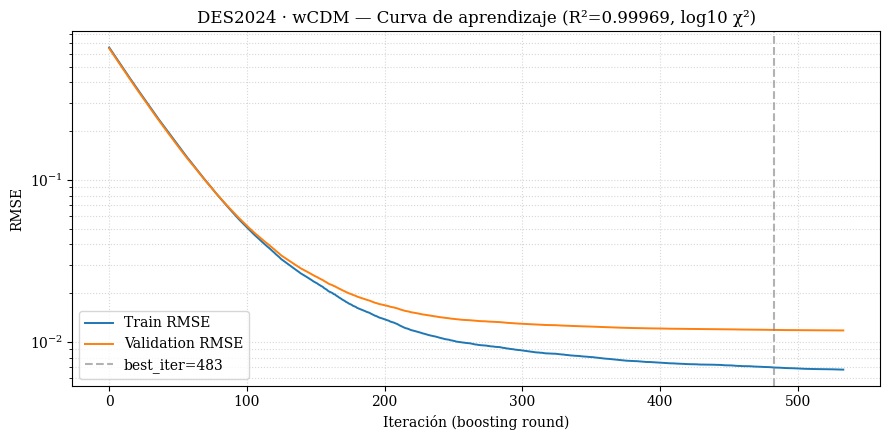

In [5]:
plot_learning_curve(
    info,
    title=f"DES2024 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_Om_w.png


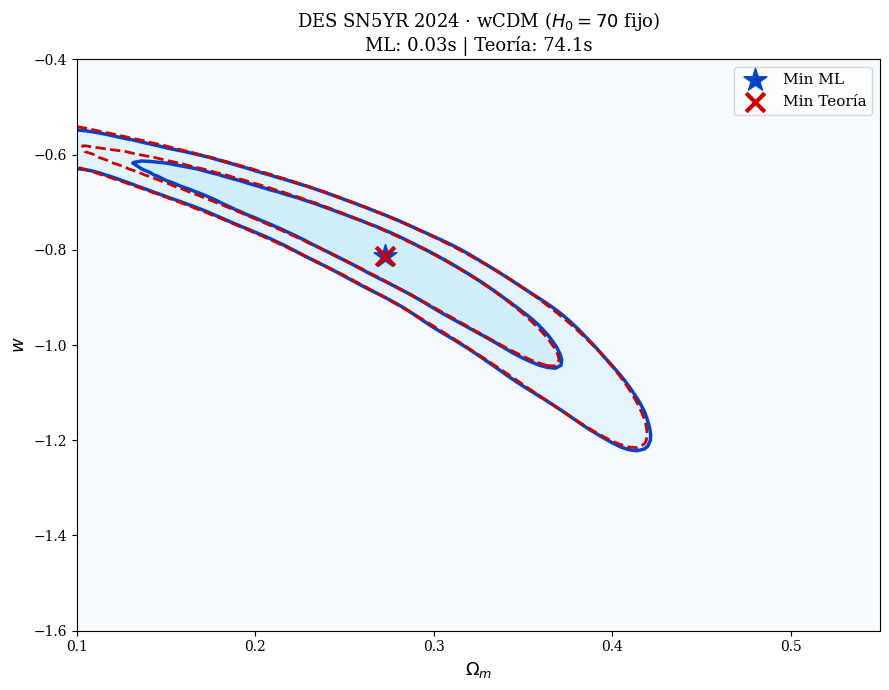

{'Z_ml': array([[3281.8774, 3260.5947, 3222.0852, ..., 1684.1565, 1685.7953,
         1686.7369],
        [3270.777 , 3249.4453, 3210.8792, ..., 1684.2905, 1685.9358,
         1686.8801],
        [3250.7314, 3229.35  , 3190.7532, ..., 1684.5504, 1686.2101,
         1687.161 ],
        ...,
        [1707.5485, 1708.2671, 1709.562 , ..., 1987.8535, 1990.0286,
         1991.2163],
        [1713.2854, 1714.046 , 1715.4099, ..., 1993.7931, 1995.8756,
         1997.0052],
        [1716.5503, 1717.3412, 1718.7535, ..., 1997.1837, 1999.2129,
         2000.3086]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.029405593872070312,
 'time_th': 74.10050225257874}

In [6]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(0.10, 0.55), y_range=(-1.6, -0.4),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2024 · wCDM ($H_0=70$ fijo)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
)

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_beeswarm.png


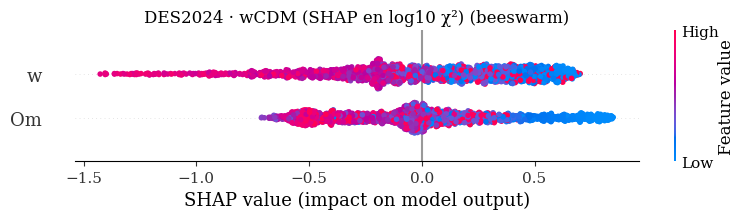

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_bar.png


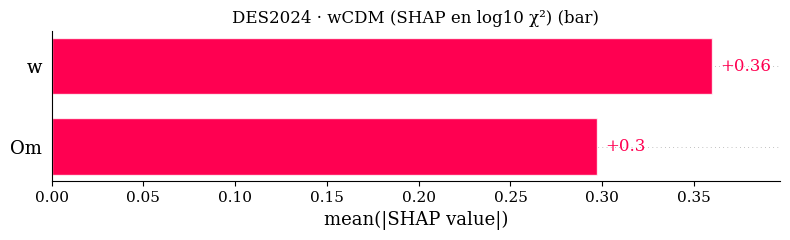

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_waterfall.png


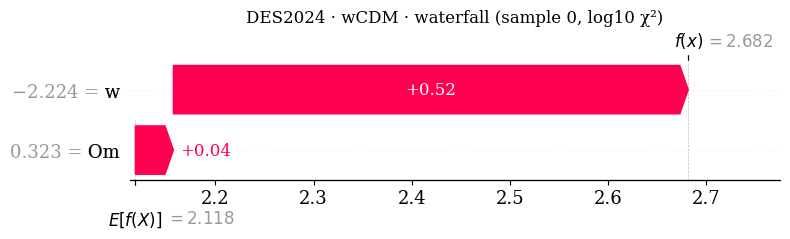

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

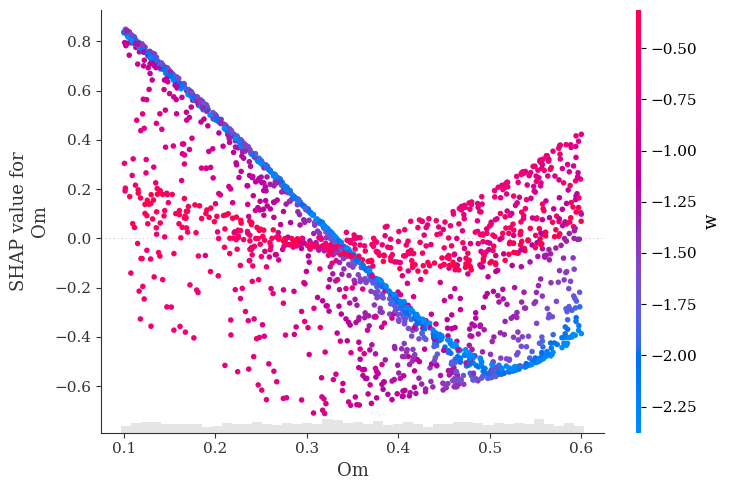

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png


<Figure size 640x480 with 0 Axes>

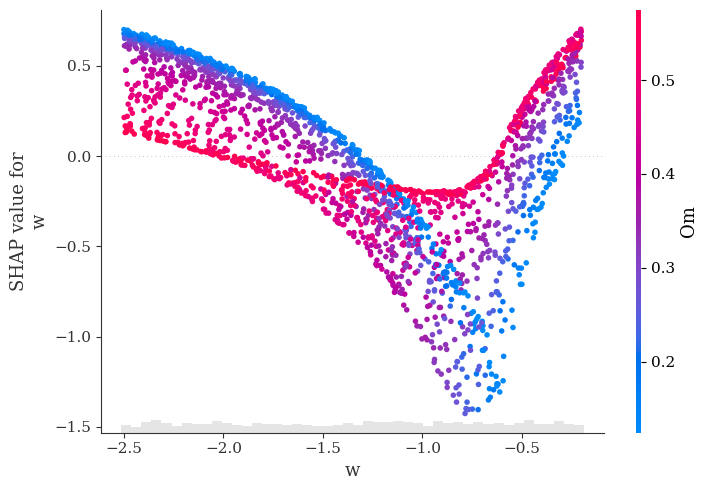

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_1_shap_w.png')]

In [7]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2024 · wCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2024 · wCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-2"></a>2.2 wCDM con DES2025 — 2D (Ω_m, w)

**Datos:** DES SN5YR release 2025 (1820 SNe, formato SNANA).
**Modelo:** `FlatwCDM` con H₀=70 fijo.
**Cefeidas:** **NO**.

Refactor de `legacy/root/wCDM_DES_2025_*`. La matriz `STAT+SYS_2025.npz` ya contiene la INVERSA de covarianza completa (STAT+SYS) en formato triangular empacado — el loader la desempaca y la usa directamente.

In [8]:
SECTION = "2_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]
REF = dict(Om=0.30, w=-1.0)
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe, z [{des.z.min():.3f}, {des.z.max():.3f}]")

def chi2_fn(Om, w):
    return chi2_sne_des(des, model="FlatwCDM", Om=Om, H0=H0_FIXED, w0=w)

print(f"χ²(LCDM ref) = {chi2_fn(**REF):.2f}")

DES SN5YR 2025: 1820 SNe, z [0.025, 1.144]
χ²(LCDM ref) = 1644.41


In [9]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.1, 0.6), w=(-2.5, -0.2)),
        n_random=20_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_2_dataset.csv
min χ² = 1639.035


In [ ]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)

  target en Shifted-Log10: rango [0.000, 3.678]
  entrenamiento: 16.87s | R²=0.99972 | best_iter=599/3000  (early stop, ahorro ~80%)
  modelo cacheado: 2_2_model.ubj


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_learning_curve.png


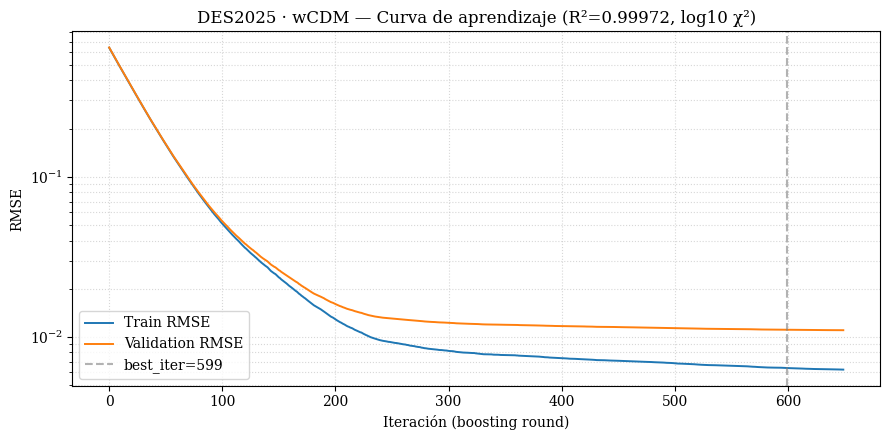

In [11]:
plot_learning_curve(
    info,
    title=f"DES2025 · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  calculando teoría (en paralelo)...


  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_Om_w.png


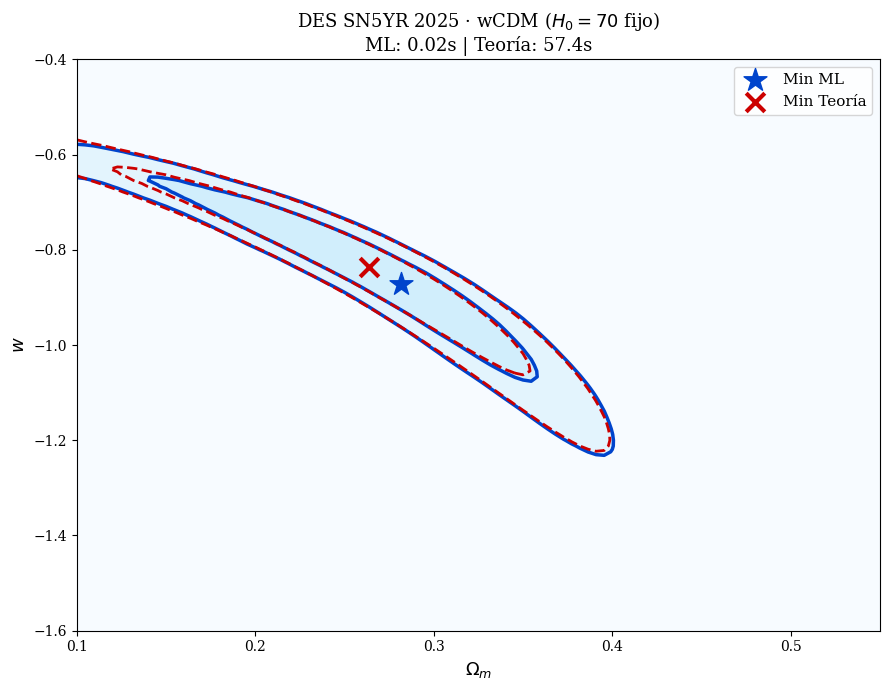

{'Z_ml': array([[3370.3008, 3344.496 , 3298.5725, ..., 1697.102 , 1699.666 ,
         1701.1306],
        [3356.5657, 3331.0234, 3285.5745, ..., 1697.403 , 1699.9752,
         1701.4423],
        [3331.4568, 3306.382 , 3261.7825, ..., 1697.9441, 1700.5312,
         1702.0026],
        ...,
        [1725.3813, 1726.2402, 1727.8281, ..., 2072.936 , 2075.5889,
         2077.0908],
        [1732.6494, 1733.5227, 1735.1394, ..., 2079.3809, 2081.925 ,
         2083.3691],
        [1736.8499, 1737.7255, 1739.3497, ..., 2082.9622, 2085.4507,
         2086.8657]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.019352436065673828,
 'time_th': 57.39919447898865}

In [12]:
common = dict(res=100, sigma=2.0, theory_threshold=12)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(0.10, 0.55), y_range=(-1.6, -0.4),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DES SN5YR 2025 · wCDM ($H_0=70$ fijo)",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
)

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_beeswarm.png


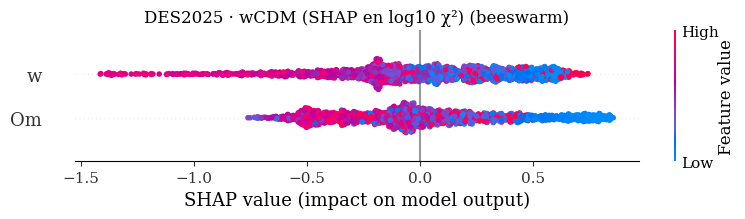

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_bar.png


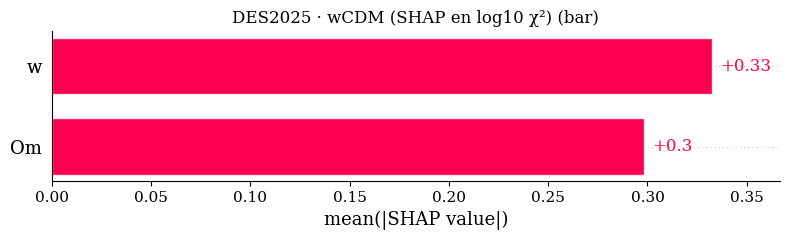

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_waterfall.png


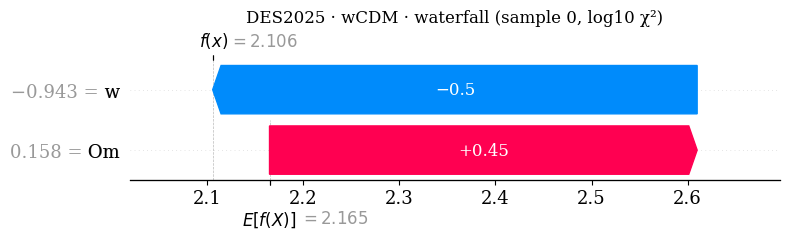

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

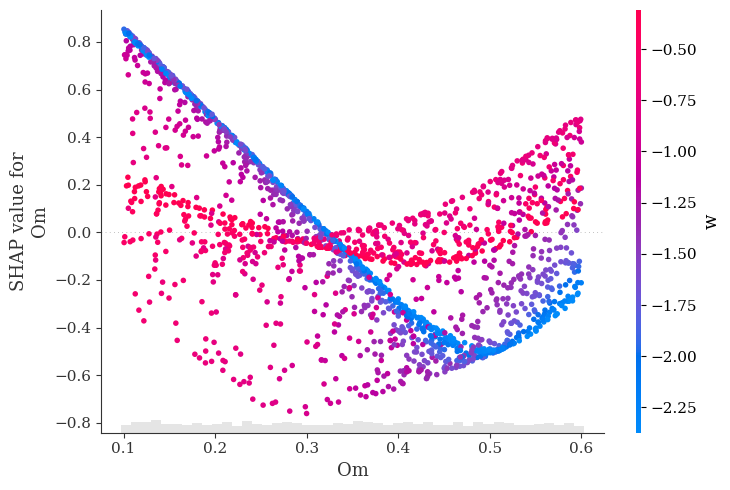

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png


<Figure size 640x480 with 0 Axes>

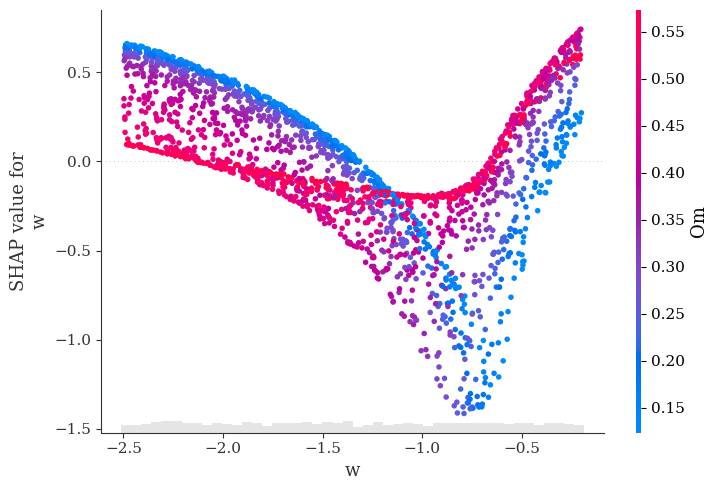

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_2_shap_w.png')]

In [13]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2025 · wCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2025 · wCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-3"></a>2.3 w₀wₐCDM con DES2024 — 3D (Ω_m, w₀, wₐ)

**Datos:** DES-SN5YR 2024.
**Modelo:** `Flatw0waCDM` (CPL) con H₀=70 fijo.
**Cefeidas:** **NO**.

Refactor de `legacy/root/w0waCDM_DES_2024_*`. **Nota:** el CSV antiguo `w0waCDM_DES2024.csv` (legacy) tenía χ²min ~6 por una mala interpretación de la matriz STAT+SYS_2024 (la trataba como inv_cov en lugar de sys_cov). Como el loader DES está corregido, el dataset se regenera correctamente cuando se ejecuta esta celda.

In [14]:
SECTION = "2_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
REF = dict(Om=0.30, w0=-1.0, wa=0.0)
H0_FIXED = 70.0

des = load_des_2024()
print(f"DES SN5YR 2024: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

print(f"χ²(LCDM ref) = {chi2_fn(**REF):.2f}")

DES SN5YR 2024: 1829 SNe
χ²(LCDM ref) = 1659.50


In [15]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.0, 0.0), wa=(-4.0, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.5), w0=(-2.0, 0.0), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.5), wa=(-4.0, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-5.0, 4.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Cargando dataset existente: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_3_dataset.csv
min χ² = 1642.532


  target en Shifted-Log10: rango [0.000, 4.097]
  entrenamiento: 16.72s | R²=0.99727 | best_iter=985/3000  (early stop, ahorro ~67%)
  modelo cacheado: 2_3_model.ubj
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_learning_curve.png


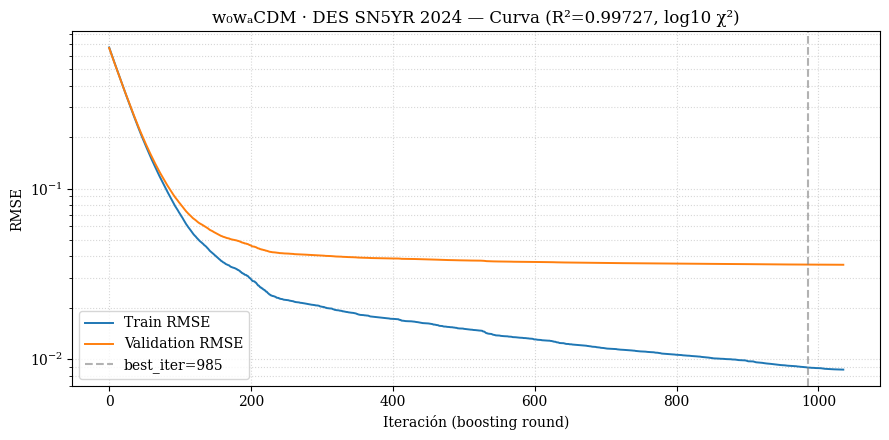

In [ ]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2024 — Curva (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_w0.png


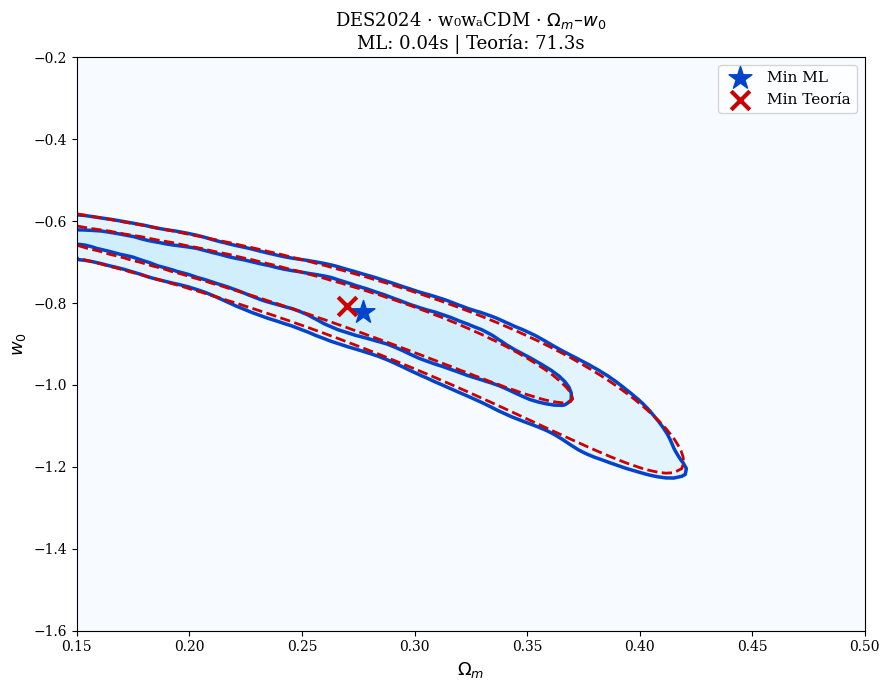

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_Om_wa.png


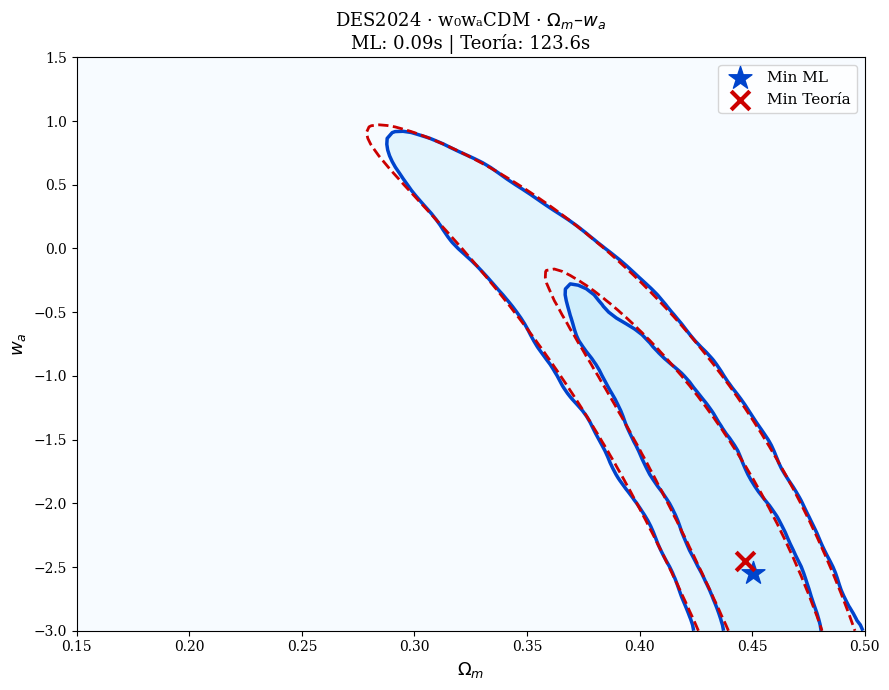

--- $w_a$ vs $w_0$  ({'Om': 0.3}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_w0_wa.png


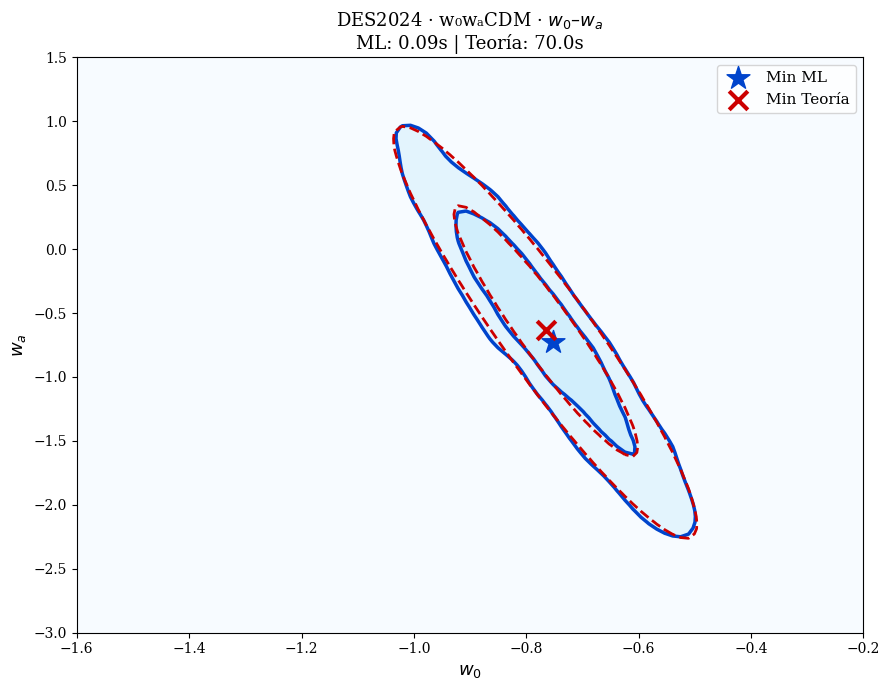

In [17]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(Om=(0.15, 0.50), w0=(-1.6, -0.2), wa=(-3.0, 1.5))
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2024 · w₀wₐCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_beeswarm.png


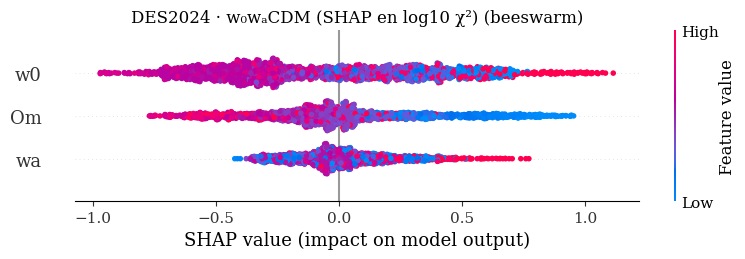

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_bar.png


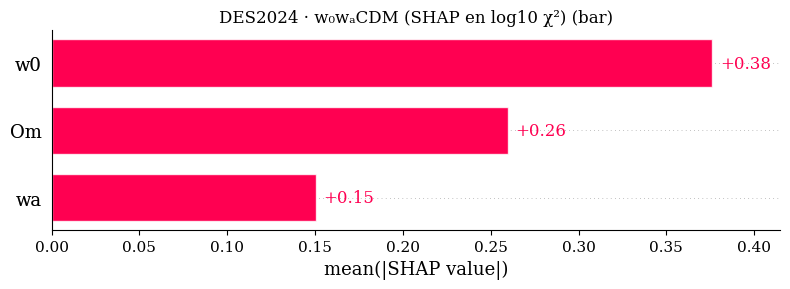

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_waterfall.png


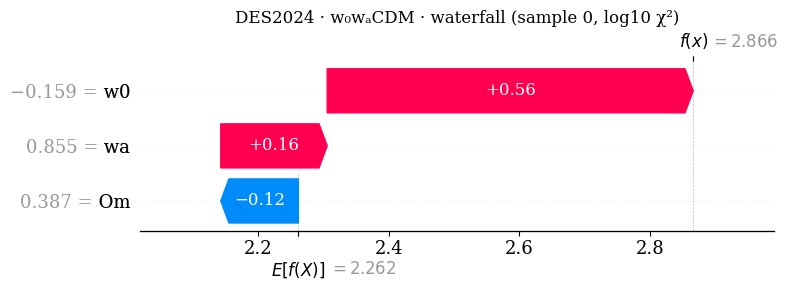

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

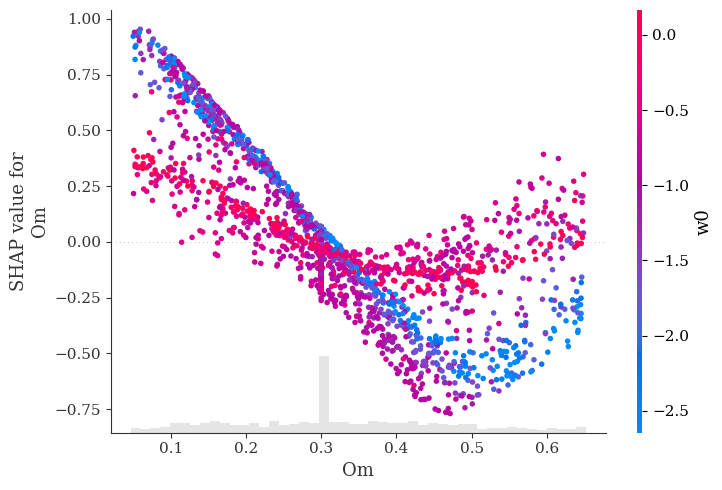

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

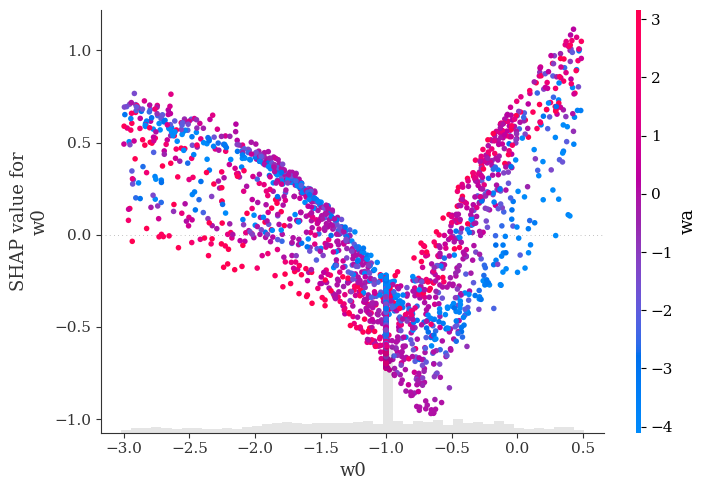

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

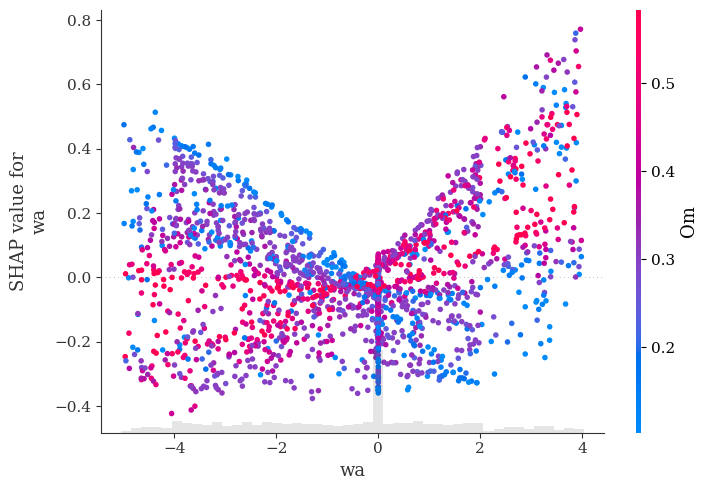

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_3_shap_wa.png')]

In [18]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2024 · w₀wₐCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2024 · w₀wₐCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="2-4"></a>2.4 w₀wₐCDM con DES2025 — 3D (Ω_m, w₀, wₐ)

**Datos:** DES SN5YR 2025 (release final).
**Modelo:** `Flatw0waCDM` (CPL) con H₀=70 fijo.
**Cefeidas:** **NO**.

Refactor de `legacy/root/w0waCDM_DES_2025_*`. Es la versión "_final" del dataset 2025 — el más actualizado del análisis SN5YR oficial.

In [19]:
SECTION = "2_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]
REF = dict(Om=0.30, w0=-1.0, wa=0.0)
H0_FIXED = 70.0

des = load_des_2025()
print(f"DES SN5YR 2025: {len(des)} SNe")

def chi2_fn(Om, w0, wa):
    return chi2_sne_des(des, model="Flatw0waCDM", Om=Om, H0=H0_FIXED, w0=w0, wa=wa)

print(f"χ²(LCDM ref) = {chi2_fn(**REF):.2f}")

DES SN5YR 2025: 1820 SNe
χ²(LCDM ref) = 1644.41


In [23]:
def builder():
    N = 5_000
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=[
            dict(w0=(-2.5, 0.2), wa=(-3.5, 2.0), Om=REF['Om'], _n=N),
            dict(Om=(0.1, 0.6), w0=(-2.5, 0.2), wa=REF['wa'],  _n=N),
            dict(Om=(0.1, 0.6), wa=(-3.5, 2.0), w0=REF['w0'],  _n=N),
        ],
        random_box=dict(Om=(0.05, 0.65), w0=(-3.0, 0.5), wa=(-4.0, 3.0)),
        n_random=15_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min χ² = {df['chi2'].min():.3f}")

Generando dataset (no existe /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_4_dataset.csv)...
Calculando χ² para 30000 puntos (en paralelo)...
  → terminado en 1442.8s
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/datasets/2_4_dataset.csv  (30000 filas)
min χ² = 1635.175


  target en Shifted-Log10: rango [0.000, 4.113]
  entrenamiento: 19.96s | R²=0.99731 | best_iter=863/3000  (early stop, ahorro ~71%)
  modelo cacheado: 2_4_model.ubj
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_learning_curve.png


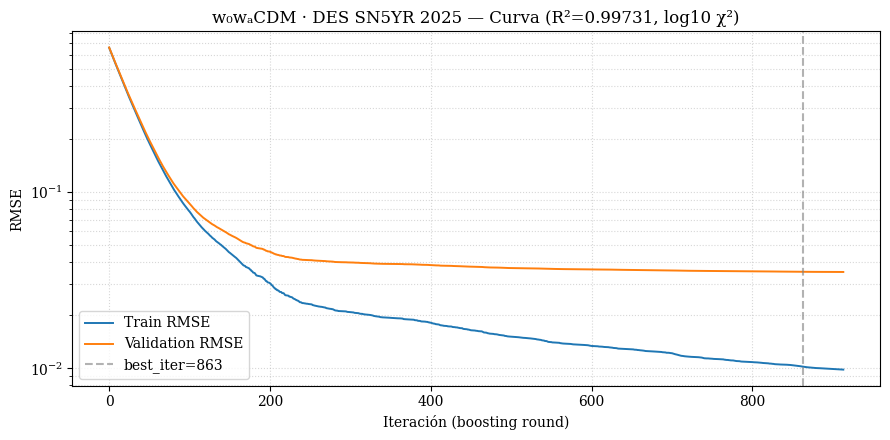

In [ ]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=False,
)
plot_learning_curve(
    info,
    title=f"w₀wₐCDM · DES SN5YR 2025 — Curva (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)


--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_w0.png


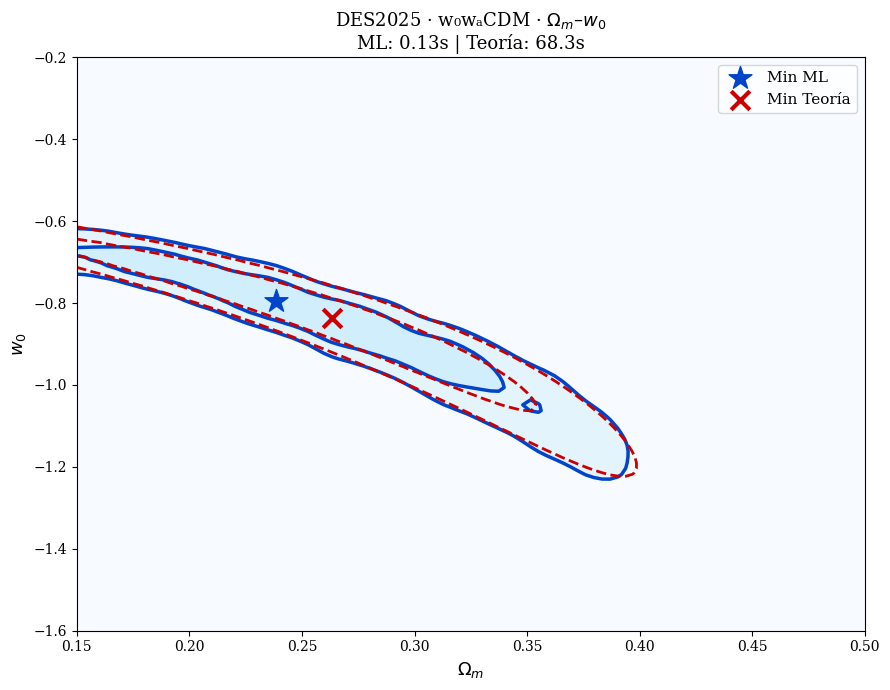

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_Om_wa.png


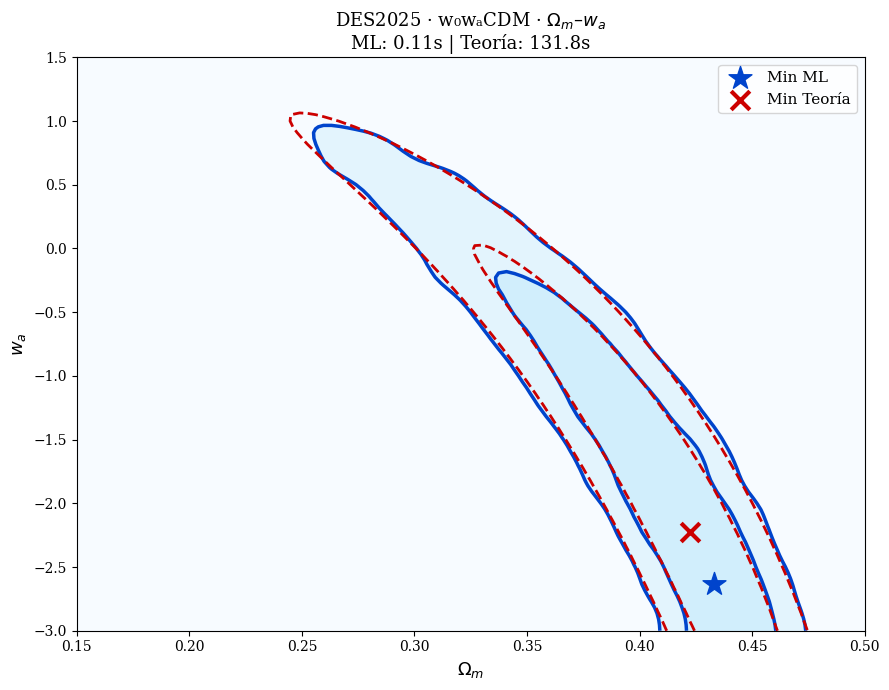

--- $w_a$ vs $w_0$  ({'Om': 0.3}) ---
  calculando teoría (en paralelo)...
  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_w0_wa.png


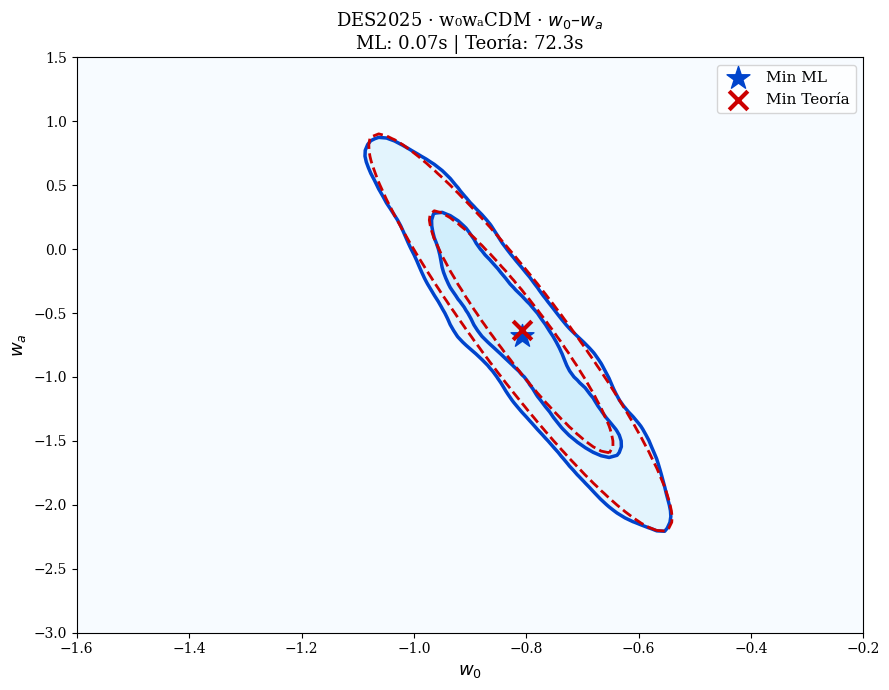

In [25]:
common = dict(res=100, sigma=2.0, theory_threshold=12)
RANGES = dict(Om=(0.15, 0.50), w0=(-1.6, -0.2), wa=(-3.0, 1.5))
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$")

for x, y in [('Om','w0'), ('Om','wa'), ('w0','wa')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DES2025 · w₀wₐCDM · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
    )

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_beeswarm.png


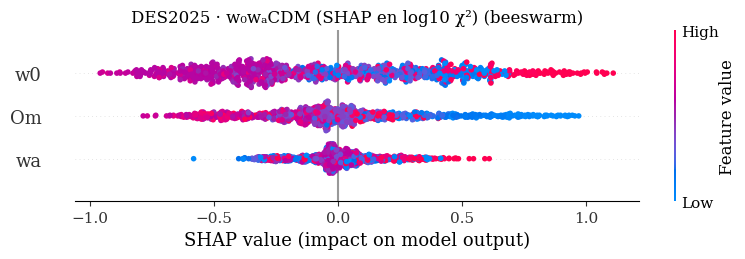

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_bar.png


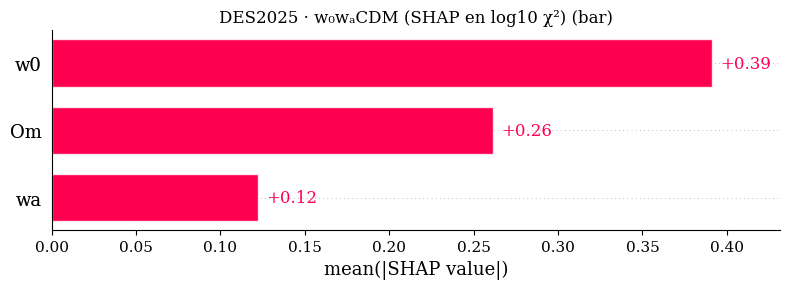

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_waterfall.png


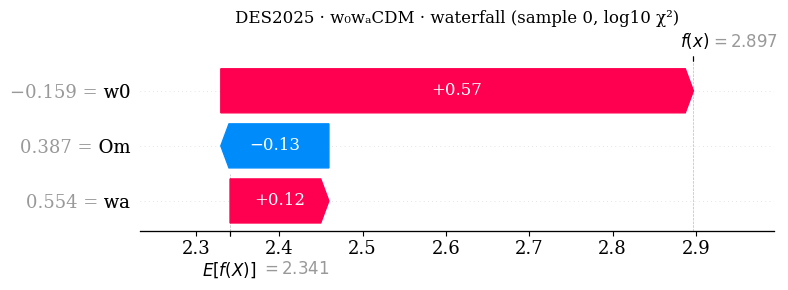

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

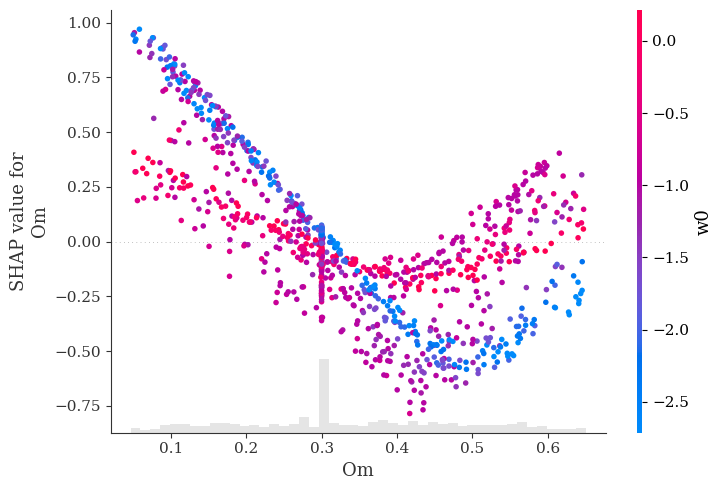

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

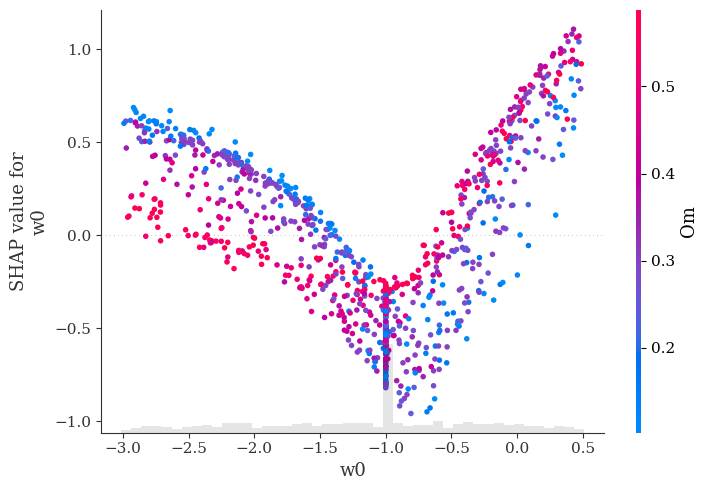

  guardado: /home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

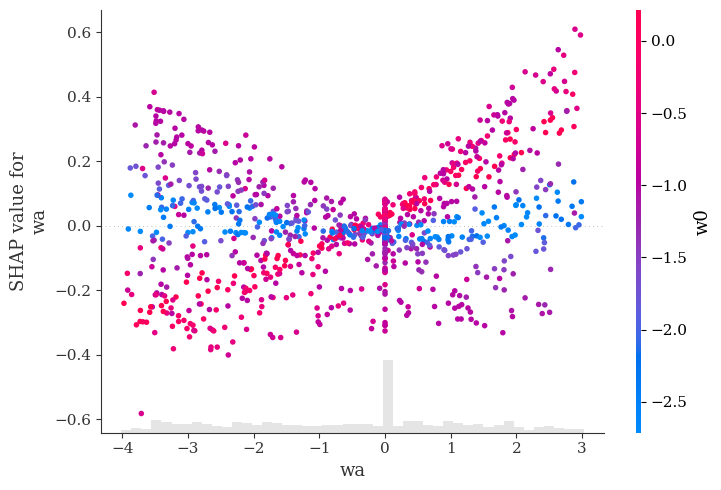

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/02_SN_DES/2_4_shap_wa.png')]

In [26]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DES2025 · w₀wₐCDM (SHAP en log10 χ²)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DES2025 · w₀wₐCDM · waterfall (sample 0, log10 χ²)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)